In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import random
random.seed(42)

In [2]:
data = pd.read_csv("../../data/ice_cream_sales.csv")
data.head()

,ID,Temperature,Is_Weekend,Hours_Open,Electricity_Usage,Ice_Cream_Sales
0,1,24.273285,False,10,92.118314,983
1,2,25.503474,False,9,83.917817,1018
2,3,24.370024,False,8,88.290617,951
3,4,24.377495,False,10,85.561865,1012
4,5,26.632614,False,8,94.404976,1010


In [3]:
data['High_Electricity_Usage'] = (data['Electricity_Usage'] > data['Electricity_Usage'].median()).astype(int)
data.head()

,ID,Temperature,Is_Weekend,Hours_Open,Electricity_Usage,Ice_Cream_Sales,High_Electricity_Usage
0,1,24.273285,False,10,92.118314,983,1
1,2,25.503474,False,9,83.917817,1018,0
2,3,24.370024,False,8,88.290617,951,1
3,4,24.377495,False,10,85.561865,1012,0
4,5,26.632614,False,8,94.404976,1010,1


In [4]:
X = data[['Temperature', 'Hours_Open']]  # Covariates
y = data['High_Electricity_Usage']  # Treatment indicator

log_reg = LogisticRegression()
log_reg.fit(X, y)

# Get the propensity scores
data['Propensity_Score'] = log_reg.predict_proba(X)[:, 1]

In [5]:
from sklearn.neighbors import NearestNeighbors

# Separate treatment and control groups
treated = data[data['High_Electricity_Usage'] == 1]
control = data[data['High_Electricity_Usage'] == 0]

# Use nearest neighbors to match treated units to control units based on propensity score
nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(control[['Propensity_Score']])

control["Cluster"] = nn.kneighbors(control[['Propensity_Score']])[1].flatten()

# Find the nearest neighbors for each treated unit
treated["Cluster"] = nn.kneighbors(treated[['Propensity_Score']])[1].flatten()

# Find the matcing control unit for each treated unit
matched_df = pd.merge(control, treated, on="Cluster", suffixes=('_control', '_treated'), how='right')

/var/folders/44/n2vfbt0d0ts_x6pggv0lhlkc0000gn/T/ipykernel_16886/3364253651.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control["Cluster"] = nn.kneighbors(control[['Propensity_Score']])[1].flatten()
/var/folders/44/n2vfbt0d0ts_x6pggv0lhlkc0000gn/T/ipykernel_16886/3364253651.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  treated["Cluster"] = nn.kneighbors(treated[['Propensity_Score']])[1].flatten()


In [6]:
# Calculate the absolute difference between propensity scores for each row
matched_df['Propensity_Score_Difference'] = abs(matched_df['Propensity_Score_treated'] - matched_df['Propensity_Score_control'])

# # Get the index of the row with the minimum propensity score difference for each cluster
closest_rows_idx = matched_df.groupby('Cluster')['Propensity_Score_Difference'].idxmin()

# # Keep only the rows with the closest propensity score difference for each cluster
closest_rows = matched_df.loc[closest_rows_idx]

closest_rows["Treatment_Effect"] = closest_rows["Ice_Cream_Sales_treated"] - closest_rows["Ice_Cream_Sales_control"]

In [7]:
# Calculate the difference in Ice_Cream_Sales between treated and matched control groups
att = np.mean(closest_rows['Ice_Cream_Sales_treated'] - closest_rows['Ice_Cream_Sales_control'])

print(f'Average Treatment Effect on the Treated (ATT): {att}')

Average Treatment Effect on the Treated (ATT): 2.2133333333333334


In [10]:
att * len(treated)/len(data)

1.1066666666666667

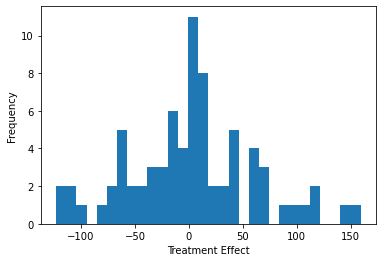

In [8]:
plt.hist(closest_rows['Treatment_Effect'], bins=30)
plt.xlabel('Treatment Effect')
plt.ylabel('Frequency')
plt.show()

In [9]:
closest_rows["Treatment_Effect"].quantile([0.025, 0.975])

0.025   -111.90
0.975    122.05
Name: Treatment_Effect, dtype: float64